Phase 0 : Récupérer la donnée et l'ouvrir

L'intendance d'abord. Le dataset Telco Churn est public sur Kaggle. Téléchargez le CSV ( WA_Fn-UseC_-Telco-Customer-Churn.csv ), déposez-le dans votre environnement (un upload dans Google Colab, le notebook gratuit de Google qui tourne dans le navigateur sans rien installer, ou à côté de votre notebook en local), et chargez-le.

In [109]:
import pandas as pd
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Phase 1 : L'audit qualité

Avant de toucher quoi que ce soit, on diagnostique. Écrivez une fonction qui produit un rapport de santé du dataset : dimensions, types, taux de manquants par colonne, et surtout l'équilibre de la cible ( Churn ).

In [ ]:
def audit_qualite(df):
    """Affiche un rapport de santé du dataset.
    Doit montrer : forme, types, % de manquants par colonne (triés),
    et la répartition de la cible Churn (en valeur ET en pourcentage).
    """
    # TODO : afficher la forme (lignes, colonnes)
    print("Forme :", df.shape)
    # TODO : pour chaque colonne, le pourcentage de valeurs manquantes, trié décroissant
    pourcentage = (df.isna().mean() * 100).round(1)
    manquants = (pourcentage > 0).sum()
    print(f"Manquants détectés : {manquants} colonne(s) (méfiance : des trous sont peut-être cachés, voir Phase 2)")
    if manquants > 0:
        print(pourcentage[pourcentage > 0].sort_values(ascending=False))
    # TODO : la répartition de la cible Churn en nombre et en %
    valeurs = df['Churn'].value_counts()
    pourcentages = df['Churn'].value_counts(normalize=True) * 100
    print("Répartition de la cible Churn :")
    for value, count in valeurs.items():
        percentage = pourcentages[value]
        print(f"Churn  {value} : {count} ({percentage:.1f}%)")

    pass

In [24]:
print("--- 1. CAS NORMAL ---")
audit_qualite(df)
print("\n--- 2. CAS LIMITE ---")
df_limite = df[df['Churn'] == 'Yes']
audit_qualite(df_limite)
print("\n--- 3. CAS ADVERSARIAL ---")
print("Sur ce dataset Telco, le cas normal est le cas adversarial (environ 73% Non / 27% Oui)")

--- 1. CAS NORMAL ---
Forme : (7043, 21)
Manquants détectés : 0 colonne(s) (méfiance : des trous sont peut-être cachés, voir Phase 2)
Répartition de la cible Churn :
Churn  No : 5174 (73.5%)
Churn  Yes : 1869 (26.5%)

--- 2. CAS LIMITE ---
Forme : (1869, 21)
Manquants détectés : 0 colonne(s) (méfiance : des trous sont peut-être cachés, voir Phase 2)
Répartition de la cible Churn :
Churn  Yes : 1869 (100.0%)

--- 3. CAS ADVERSARIAL ---
Sur ce dataset Telco, le cas normal est le cas adversarial (environ 73% Non / 27% Oui)


Phase 2 : La colonne piégée (types incohérents et trous cachés)

Le Telco a un piège célèbre : la colonne TotalCharges est stockée en texte ( object ) alors que ce sont des montants, parce que quelques lignes contiennent un espace " " au lieu d'un nombre. Des trous déguisés. Repérez-les, convertissez la colonne en numérique, et traitez les manquants ainsi révélés.

In [51]:
def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés.
    Doit renvoyer le df réparé et afficher combien de trous ont été démasqués.
    """
    # TODO : convertir TotalCharges en numérique (pd.to_numeric, errors="coerce"
    # transforme les valeurs illisibles en NaN)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    # TODO : compter et afficher combien de NaN sont apparus
    nan_count = df['TotalCharges'].isna().sum()
    print(f"Nombre de trous démasqués : {nan_count}")
    # TODO : imputer ces trous (médiane) ou décider de supprimer ces lignes : justifiez
    mediane = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(mediane)    
    print("Trous imputés avec la médiane (stratégie choisie pour ne pas perdre de données, car il n'y a que quelques trous).")
    return df

In [110]:
df = reparer_total_charges(df)
print("\n--- APRÈS RÉPARATION DE TotalCharges ---")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Nombre de trous démasqués : 11
Trous imputés avec la médiane (stratégie choisie pour ne pas perdre de données, car il n'y a que quelques trous).

--- APRÈS RÉPARATION DE TotalCharges ---
Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Phase 3 : Encoder les catégorielles    

Le Telco regorge de colonnes texte : gender , Contract , PaymentMethod , des tas de Yes/No ... Un modèle ne les lit pas. Encodez-les proprement, en distinguant nominal et ordinal comme ce matin.

In [ ]:
def encoder_features(df):
    """Encode toutes les colonnes catégorielles.
    Doit renvoyer un df 100% numérique, prêt pour un modèle.
    """
    # TODO : repérer les colonnes catégorielles (dtype object)
    colonnes_object = df.select_dtypes(include='object').columns
    # TODO : pour les binaires Yes/No, un encodage simple 0/1
    df = df.replace({'Yes': 1, 'No': 0})
    # TODO : décider du sort de customerID (indice : un identifiant n'est PAS une feature)
    if 'customerID' in df.columns:
        df = df.drop(columns=['customerID'])
        print("Colonne customerID supprimée (identifiant, pas une feature).")

    # TODO : pour les nominales (PaymentMethod, Contract...), du One-Hot
    df = pd.get_dummies(df, drop_first=True)    

    return df

In [59]:
df = encoder_features(df)
print("\n--- APRÈS ENCODAGE ---")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Colonne customerID supprimée (identifiant, pas une feature).

--- APRÈS ENCODAGE ---
Forme : (7043, 31)
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
gender_Male                                 bool
MultipleLines_1                             bool
MultipleLines_No phone service              bool
InternetService_DSL                         bool
InternetService_Fiber optic                 bool
OnlineSecurity_1                            bool
OnlineSecurity_No internet service          bool
OnlineBackup_1                              bool
OnlineBackup_No internet service            bool
DeviceProtecti

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_No internet service,StreamingTV_1,StreamingTV_No internet service,StreamingMovies_1,StreamingMovies_No internet service,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,29.85,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,34,1,0,56.95,1889.50,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,2,1,1,53.85,108.15,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,45,0,0,42.30,1840.75,0,True,...,False,False,False,False,False,True,False,False,False,False
4,0,0,0,2,1,1,70.70,151.65,1,False,...,False,False,False,False,False,False,False,False,True,False


Phase 4 : Traiter les valeurs aberrantes

Les colonnes numériques ( tenure , MonthlyCharges , TotalCharges ) ont-elles des outliers ? Détectez-les avec la règle IQR vue ce matin, visualisez-les en boxplot, et décidez d'une stratégie par colonne (garder,plafonner, supprimer), en la justifiant.

In [63]:
def detecter_outliers_iqr(df, colonne):
    """Renvoie les bornes IQR et le nombre d'outliers d'une colonne numérique.
    Doit renvoyer (borne_basse, borne_haute, nombre_outliers).
    """
    # TODO : calculer Q1, Q3, IQR
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    print(f"Colonne {colonne} : Q1={Q1}, Q3={Q3}, IQR={IQR}")
    # TODO : déduire les bornes (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    # TODO : compter les points hors bornes
    outliers = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)]
    nombre_outliers = outliers.shape[0]
    return borne_basse, borne_haute, nombre_outliers
    

Colonne MonthlyCharges : Q1=35.5, Q3=89.85, IQR=54.349999999999994
Comportement normal : MonthlyCharges entre -46.02 et 171.38 avec 0 outliers détectés.
Colonne Tenure : Q1=50.0, Q3=50.0, IQR=0.0
Comportement sans outliers : Tenure entre 50.00 et 50.00 avec 0 outliers détectés.
Colonne TotalCharges : Q1=402.225, Q3=3786.6, IQR=3384.375
Comportement avec suppression : TotalCharges entre -4674.34 et 8863.16 avec 0 outliers détectés.


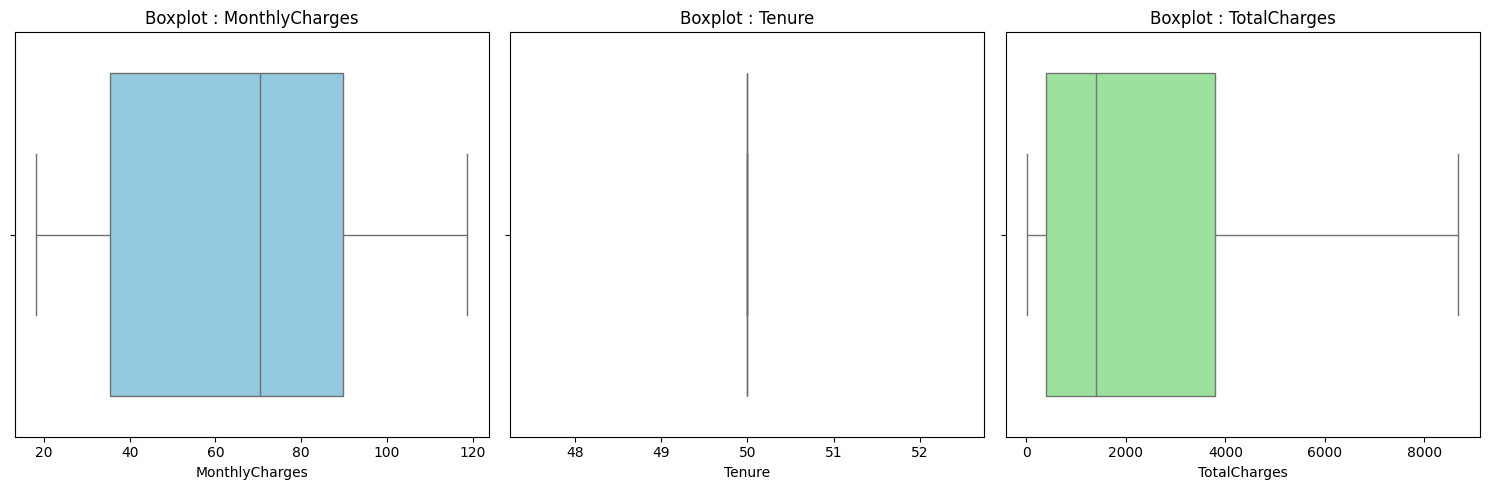

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonne normale 
base_normal, haute_normal, nb_outliers_normal = detecter_outliers_iqr(df, colonne='MonthlyCharges')
print(f"Comportement normal : MonthlyCharges entre {base_normal:.2f} et {haute_normal:.2f} avec {nb_outliers_normal} outliers détectés.")

# Colonne sans outliers
df['Tenure'] = 50
base_sans_outliers, haute_sans_outliers, nb_outliers_sans_outliers = detecter_outliers_iqr(df, colonne='Tenure')
print(f"Comportement sans outliers : Tenure entre {base_sans_outliers:.2f} et {haute_sans_outliers:.2f} avec {nb_outliers_sans_outliers} outliers détectés.")

# Colonne où on supprime les outliers
base_supprime, haute_supprime, nb_outliers_supprime = detecter_outliers_iqr(df, colonne='TotalCharges')
print(f"Comportement avec suppression : TotalCharges entre {base_supprime:.2f} et {haute_supprime:.2f} avec {nb_outliers_supprime} outliers détectés.")

plt.figure(figsize=(15, 5))

# Premier boxplot pour MonthlyCharges 
plt.subplot(1, 3, 1)
sns.boxplot(x=df['MonthlyCharges'], color='skyblue')
plt.title('Boxplot : MonthlyCharges')

# Deuxième boxplot pour Tenure 
plt.subplot(1, 3, 2)
sns.boxplot(x=df['Tenure'], color='salmon')
plt.title('Boxplot : Tenure')

# Troisième boxplot pour TotalCharges 
plt.subplot(1, 3, 3)
sns.boxplot(x=df['TotalCharges'], color='lightgreen')
plt.title('Boxplot : TotalCharges')

plt.tight_layout()
plt.show()

Phase 5 : Corrélations et chasse à la multicolinéarité

Tracez la heatmap des corrélations sur les colonnes numériques. Repérez les variables redondantes (indice : tenure , MonthlyCharges et TotalCharges ne sont pas indépendantes, le total c'est grosso modo le mensuel multiplié par l'ancienneté). Calculez les VIF, et décidez quelles colonnes supprimer.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def rapport_multicolinearite(df, colonnes_num):
    """Affiche la heatmap des corrélations et le VIF de chaque colonne numérique.
    Doit aider à décider quelle(s) colonne(s) redondante(s) supprimer.
    """
    
    X = df[colonnes_num].dropna()
    
    # TODO : heatmap seaborn des corrélations (Syntaxe exacte du cours)
    plt.figure(figsize=(8, 6))
    sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Heatmap des corrélations")
    plt.show()
    
    # TODO : tableau des VIF (Syntaxe exacte de la page 14)
    vif = pd.DataFrame()
    vif["variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print("\n--- Tableau complet des VIF ---")
    print(vif)
    
    # TODO : signaler les colonnes au VIF > 5
    vif_alerte = vif[vif["VIF"] > 5]
    print("\nColonnes au VIF > 5 :")
    print(vif_alerte)

--- 1. HAPPY PATH ---


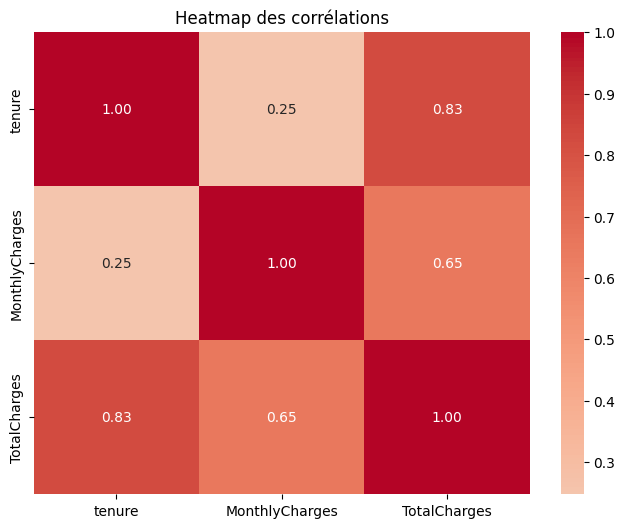


--- Tableau complet des VIF ---
         variable       VIF
0          tenure  6.321802
1  MonthlyCharges  3.360371
2    TotalCharges  8.073814

Colonnes au VIF > 5 :
       variable       VIF
0        tenure  6.321802
2  TotalCharges  8.073814

--- 2. EDGE CASE (Colonnes identiques) ---


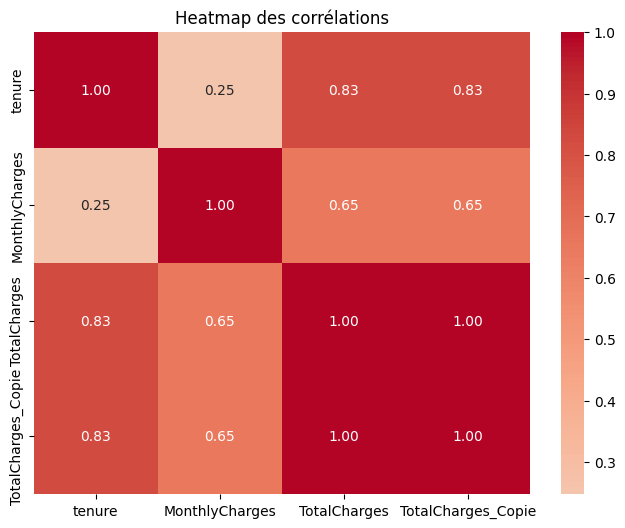


--- Tableau complet des VIF ---
             variable       VIF
0              tenure  6.321802
1      MonthlyCharges  3.360371
2        TotalCharges       inf
3  TotalCharges_Copie       inf

Colonnes au VIF > 5 :
             variable       VIF
0              tenure  6.321802
2        TotalCharges       inf
3  TotalCharges_Copie       inf

--- 3. ADVERSARIAL (Suppression de TotalCharges) ---


c:\Users\maxim\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


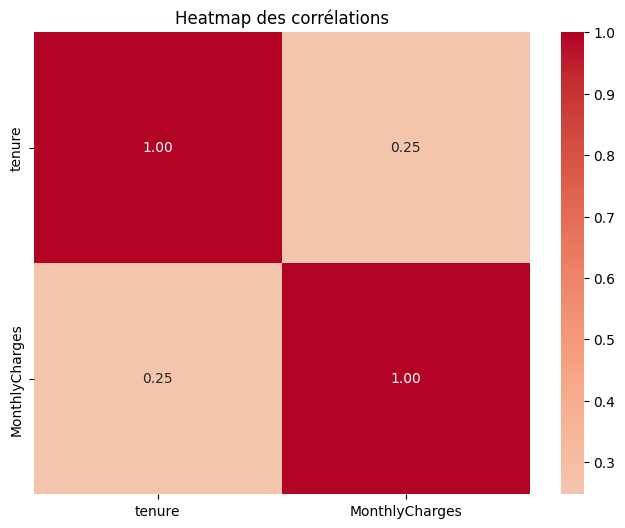


--- Tableau complet des VIF ---
         variable       VIF
0          tenure  2.612607
1  MonthlyCharges  2.612607

Colonnes au VIF > 5 :
Empty DataFrame
Columns: [variable, VIF]
Index: []


In [ ]:
print("--- 1. HAPPY PATH ---")
rapport_multicolinearite(df, ['tenure', 'MonthlyCharges', 'TotalCharges'])

print("\n--- 2. EDGE CASE (Colonnes identiques) ---")
df_edge = df.copy()
df_edge['TotalCharges_Copie'] = df_edge['TotalCharges']
rapport_multicolinearite(df_edge, ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_Copie'])

print("\n--- 3. ADVERSARIAL (Suppression de TotalCharges) ---")
rapport_multicolinearite(df, ['tenure', 'MonthlyCharges'])

Phase 6 : Les variables qui prédisent vraiment le churn

Maintenant, le tri par pouvoir prédictif. Quelles features sont les plus liées à la résiliation ? Croisez deux
approches (corrélation à la cible et importance via un Random Forest) et produisez un classement.

In [93]:
from sklearn.ensemble import RandomForestClassifier

def features_discriminantes(df, cible="Churn"):
    """Classe les features par pouvoir prédictif sur la cible.
    Doit afficher un top 10 selon au moins deux méthodes.
    """
    
    # TODO : corrélation (ou information mutuelle) de chaque feature à la cible
    matrice_corr = df.corr()
    corr_cible = matrice_corr[cible].abs()
    corr_cible = corr_cible.drop(cible)
    top_corr = corr_cible.sort_values(ascending=False).head(10)
    
    
    # TODO : importance via un RandomForestClassifier
    X = df.drop(columns=[cible])
    y = df[cible]
    
    rfc = RandomForestClassifier(random_state=42)
    rfc.fit(X, y)
    
    importances_rfc = pd.Series(rfc.feature_importances_, index=X.columns)
    top_rfc = importances_rfc.sort_values(ascending=False).head(10)
    
    
    # TODO : afficher les deux classements côte à côte
    df_comparaison = pd.DataFrame({
        "Top 10 Corrélation": top_corr.index,
        "Score Corr": top_corr.values.round(3),
        "Top 10 Random Forest": top_rfc.index,
        "Score RF": top_rfc.values.round(3)
    })
    
    print("\n-Top 10 des features les plus prédictives")
    print(df_comparaison)

In [94]:
print("happy path ")
features_discriminantes(df)

print("Edge case ")
df_edge = df.copy()
df_edge['Colonne_Constante_Inutile'] = 1
features_discriminantes(df_edge)

happy path 

-Top 10 des features les plus prédictives
                     Top 10 Corrélation  Score Corr  \
0                                tenure       0.352   
1           InternetService_Fiber optic       0.308   
2                     Contract_Two year       0.302   
3        PaymentMethod_Electronic check       0.302   
4       TechSupport_No internet service       0.228   
5    OnlineSecurity_No internet service       0.228   
6  DeviceProtection_No internet service       0.228   
7   StreamingMovies_No internet service       0.228   
8       StreamingTV_No internet service       0.228   
9      OnlineBackup_No internet service       0.228   

             Top 10 Random Forest  Score RF  
0                    TotalCharges     0.201  
1                          tenure     0.168  
2                  MonthlyCharges     0.164  
3  PaymentMethod_Electronic check     0.043  
4     InternetService_Fiber optic     0.037  
5                     gender_Male     0.028  
6               C

Phase 7 : Split, scaling, et le grand piège de la fuite

Le coeur du métier, et l'erreur qui coûte le plus cher en entreprise. Vous allez assembler tout le preprocessing
dans le BON ordre, en respectant la règle d'or : tout ce qui s'apprend sur la donnée (moyennes
d'imputation, bornes de scaling) s'apprend sur le TRAIN seulement, jamais sur le test.

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def split_et_scale_proprement(X, y):
    """Sépare train/test PUIS ajuste le scaler sur le train seul.
    Doit renvoyer X_train_scaled, X_test_scaled, y_train, y_test.
    """
    # TODO : train_test_split (avec stratify=y pour garder l'équilibre du churn)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    # TODO : ajuster le StandardScaler sur X_train SEULEMENT (fit_transform)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    # TODO : appliquer ce même scaler à X_test (transform, PAS fit_transform)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test

In [100]:
X = df.drop(columns=['Churn'])
y = df['Churn']

# Version honnête 
X_train_h, X_test_h, y_train_h, y_test_h = split_et_scale_proprement(X, y)
modele_honnete = LogisticRegression(random_state=42, max_iter=1000)
modele_honnete.fit(X_train_h, y_train_h)
score_honnete = accuracy_score(y_test_h, modele_honnete.predict(X_test_h))

# Version qui triche 
scaler_triche = StandardScaler()
X_scaled_triche = scaler_triche.fit_transform(X)
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_scaled_triche, y, test_size=0.2, stratify=y, random_state=42)

modele_triche = LogisticRegression(random_state=42, max_iter=1000)
modele_triche.fit(X_train_t, y_train_t)
score_triche = accuracy_score(y_test_t, modele_triche.predict(X_test_t))

print(f"Accuracy de la version Honnête : {score_honnete:.5f}")
print(f"Accuracy de la version Triche  : {score_triche:.5f}")

Accuracy de la version Honnête : 0.80696
Accuracy de la version Triche  : 0.80696


Phase 8 : La boîte à outils réutilisable

In [102]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

class DataCleaner:
    """Apprend le nettoyage sur le train, le rejoue à l'identique sur toute donnée nouvelle."""
    
    def __init__(self):
        self.medians_ = {}
        self.scaler_ = StandardScaler()
        self.ohe_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False) 
        self.cols_to_drop_ = ['customerID', 'TotalCharges'] # TotalCharges a un VIF trop élevé
        
        self.num_cols_ = []
        self.cat_cols_ = []

    def fit(self, df):
        X = df.drop(columns=[c for c in self.cols_to_drop_ if c in df.columns])
        self.num_cols_ = X.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols_ = X.select_dtypes(include=['object', 'category']).columns.tolist()

        for col in self.num_cols_:
            self.medians_[col] = X[col].median()

        X_num_filled = X[self.num_cols_].fillna(self.medians_)
        self.scaler_.fit(X_num_filled)

        if self.cat_cols_:
            self.ohe_.fit(X[self.cat_cols_].fillna('Missing'))

        return self

    def transform(self, df):
        X = df.drop(columns=[c for c in self.cols_to_drop_ if c in df.columns])

        X_num_filled = X[self.num_cols_].fillna(self.medians_)
        X_num_scaled = pd.DataFrame(
            self.scaler_.transform(X_num_filled), 
            columns=self.num_cols_, 
            index=X.index
        )

        if self.cat_cols_:
            X_cat_encoded = pd.DataFrame(
                self.ohe_.transform(X[self.cat_cols_].fillna('Missing')),
                columns=self.ohe_.get_feature_names_out(self.cat_cols_),
                index=X.index
            )
            return pd.concat([X_num_scaled, X_cat_encoded], axis=1)
        
        return X_num_scaled

    def fit_transform(self, df):
        return self.fit(df).transform(df)

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

cleaner = DataCleaner()
X_train_clean = cleaner.fit_transform(X_train)
X_test_clean = cleaner.transform(X_test)

# --- LES TESTS ---

# TEST 1 : Happy Path
assert X_train_clean.isna().sum().sum() == 0, "Échec : Il reste des trous !"
assert list(X_train_clean.columns) == list(X_test_clean.columns), "Échec : Train et Test non alignés"

# TEST 2 : Edge Case 
X_test_une_ligne = cleaner.transform(X_test.head(1))
assert X_test_une_ligne.shape[0] == 1, "Échec : Ne gère pas une ligne isolée."

# TEST 3 : Adversarial
X_test_piege = X_test.copy()
X_test_piege.iloc[0, X_test_piege.columns.get_loc('PaymentMethod')] = 'Paiement_Inconnu_Bitcoin'

X_test_piege_clean = cleaner.transform(X_test_piege)
assert list(X_train_clean.columns) == list(X_test_piege_clean.columns), "Échec ADVERSARIAL : Colonne créée/supprimée !"

print("Tous les tests sont passés ! Le DataCleaner est robuste sur des données brutes.")

Tous les tests sont passés ! Le DataCleaner est robuste sur des données brutes.


In [112]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cols_to_drop = ['customerID', 'TotalCharges']
X_train_reduit = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])

num_features = X_train_reduit.select_dtypes(include=['number']).columns.tolist()
cat_features = X_train_reduit.select_dtypes(include=['object', 'category']).columns.tolist()

# TODO : un pipeline numérique (imputation médiane -> scaling)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# TODO : un pipeline catégoriel (imputation mode -> OneHotEncoder handle_unknown="ignore")
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# TODO : assembler les deux avec ColumnTransformer
preprocesseur = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop' 
)

# Test de la version sklearn
X_train_v2 = preprocesseur.fit_transform(X_train)
X_test_v2 = preprocesseur.transform(X_test)

print("Colonnes (version sklearn) :", X_train_v2.shape[1])
assert X_train_v2.shape[1] == X_test_v2.shape[1], "Échec : Train/Test non alignés par le ColumnTransformer"
print("Pipeline industriel validé !")

Colonnes (version sklearn) : 44
Pipeline industriel validé !
